# Studying the optical systematics of SPIDER-2 using MeepSAT

After gaining some basic insights on the capabilities of FDTD simulations on a basic single-lens-system, we are expanding our FDTD simulations for a real telescope SPIDER 2 in the following tutorial.

In [1]:
# Importing various Python libraries and MeepSAT modules
import sys
import os
import site
from pathlib import Path
import meep as mp
import numpy as np
import h5py
import matplotlib.pyplot as plt
import time
import json

# Importing the MEEPSAT librarires
import meepsat.simulator as sim
import meepsat.meep_geometry as comp_meep
import meepsat.permittivity_components as comp_eps
import meepsat.stepfunctions as stepfunctions
import meepsat.json_to_script as json_to_script
import meepsat.field_analysis as mpsat_analysis
import meepsat.helpers as mpsat_helpers

# JSON file path representing mainly the different optical components parameters
json_file_path = 'auxilary_data/02_SPIDER2/SPIDER2.json'
data = mpsat_helpers.read_json(json_file_path)

# Savepath: For storing the output generated during the simulation
savepath = 'auxilary_data/02_SPIDER2/output_files'
os.makedirs(savepath, exist_ok=True)

Using MPI version 4.1, 1 processes


In [2]:
# Initialising MEEPSAT Simulation
cell_X, cell_Y, cell_Z = data["simulation"]['primary_params']['cell_size']['x'], data["simulation"]['primary_params']['cell_size']['y'], data["simulation"]['primary_params']['cell_size']['z'] # Cell Size without considering the PML thickness and its factor


# Initialize the simulation with the different parameters
mpsat_sim = sim.sim_init(sim_name= str(data["simulation"]["name"]),
                        cell_size= [cell_X, cell_Y, cell_Z], # [sx, sy, sz] in mm
                        smallest_freq= data["simulation"]['primary_params']['smallest_freq'], 
                        resolution= data["simulation"]['primary_params']['resolution'],
                        boundary_layer_type= data['boundary_layers']['boundary']['type'],
                        boundary_layer_size= data['boundary_layers']['boundary']['size'],
                        factor_dpml= data['boundary_layers']['boundary']['factor_dpml'])


In [3]:
# # Checking resolution and PML thickness 
# # This function will automatically check all the length scales and wavelength scales
# data, mpsat_sim = sim.check_resolution_and_pml(
#     data=data, 
#     mpsat_sim=mpsat_sim,
#     smallest_freq=data["simulation"]['primary_params']['smallest_freq'],
#     highest_n=data["lenses"]["lens1"]["n_refr"]
# )

# Print the simulation parameters
print("\nMEEPSAT SIMULATION PARAMETERS:")
mpsat_sim.print_simulation_parameters()



MEEPSAT SIMULATION PARAMETERS:
Simulation name: SPIDER2
Cell size: [1162, 202, 0]
Frequency: 0.25
Wavelength: 4.0
Resolution: 8
Boundary layer type: PML
Boundary layer size: 2
Factor for PML boundary layer thickness: 1


In [4]:
source_list = []
exec(json_to_script.source_script(data))

Angle of the source:3.141592653589793 rad = 180 degrees
Additional arguments for the ContinuousSource:  {'start_time': 0, 'end_time': 1e+20}
Additional arguments for GaussianBeamSource:  {'beam_x0': Vector3<0.0, 0.0, 0.0>, 'beam_E0': Vector3<0.0, 0.0, 1.0>}
Gaussian beam source assembled!


In [5]:
x_left_boundary = mp.PML(thickness=mpsat_sim.dpml*mpsat_sim.factor_dpml, direction=mp.X, side=mp.Low)
x_right_boundary = mp.PML(thickness=mpsat_sim.dpml*mpsat_sim.factor_dpml, direction=mp.X, side=mp.High)
y_down_boundary = mp.PML(thickness=mpsat_sim.dpml*mpsat_sim.factor_dpml, direction=mp.Y, side=mp.Low)
y_up_boundary = mp.PML(thickness=mpsat_sim.dpml*mpsat_sim.factor_dpml, direction=mp.Y, side=mp.High)

custom_boundary_layers = [x_left_boundary, x_right_boundary, y_down_boundary, y_up_boundary]

In [6]:
size_x, size_y, size_z = mpsat_sim.cell_size[0], mpsat_sim.cell_size[1], mpsat_sim.cell_size[2]
res = int(mpsat_sim.resolution)  # Ensure resolution is an integer
# Create the epsilon map: total size of the simulation cell in all the axis multiplied by the resolution + 1
epsilon_map = np.ones((int((size_x)*res+1), 
                       int((size_y)*res+1)), dtype = 'float32')

In [7]:
# Adding lens (if given)
exec(json_to_script.add_lens(data))

# Adding aperture (if given)
exec(json_to_script.add_aperture(data))

Saving epsilon map to HDF5 file...
[[1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 ...
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]] added to the list of components created using the epsilon functions!
[[1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 ...
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]] added to the list of components created using the epsilon functions!
HDF5 file written to /home/ashesh/PhD_work/MeepSAT/output_files/SPIDER2_epsilon_map.h5
Aperture stop created with orientation: vertical
type material:  Medium()
Aperture stop created (vertical): Up size=Vector3<1.0, 76.0, 0.0>, Down size=Vector3<1.0, 76.0, 0.0>
Centers: Up=Vector3<-22.59403218, 63.0, 0.0>, Down=Vector3<-22.59403218, -63.0, 0.0>
<meep.geom.Block object at 0x7b653ed96270> added to the list of components created using the MEEP functions!
<meep.geom.Block object at 0x7b653ec51090> added to the lis

In [8]:
symmetries = [mp.Mirror(mp.Y, phase=+1)] 

In [9]:
simulation = mp.Simulation(
    cell_size=mpsat_sim.cell,
    sources=source_list,
    resolution=mpsat_sim.resolution,
    boundary_layers=custom_boundary_layers,
    geometry=mpsat_sim.meep_geometry,
    epsilon_input_file = data["output"]["savepath"]["path"] + data["output"]["epsilon_h5_file"]["filename"] +"_epsilon_map" + ".h5",
    symmetries = symmetries,
    force_complex_fields= True)

simulation.use_output_directory(savepath)

'auxilary_data/02_SPIDER2/output_files'

-----------
Initializing structure...
read in 9297x1617x1 epsilon-input-file "../output_files/SPIDER2_epsilon_map.h5"
Halving computational cell along direction y
time for choose_chunkdivision = 0.00283254 s
read in 9297x1617x1 epsilon-input-file "../output_files/SPIDER2_epsilon_map.h5"
Working in 2D dimensions.
Computational cell is 1162 x 202 x 0 with resolution 8
     block, center = (-22.594,63,0)
          size (1,76,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (-1e+20,-1e+20,-1e+20)
     block, center = (-22.594,-63,0)
          size (1,76,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (-1e+20,-1e+20,-1e+20)
subpixel-averaging is 96.2214% done, 0.1571 s remaining
subpixel-averaging is 98.1954% done, 0.0735122 s remaining
subpixel-averaging is 99.3798% done, 0.0249679 s remaining
time for set_epsilon = 12.6519 s
-----------
Meep: using complex fields.
Meep: using output directory 'auxilar

FloatProgress(value=0.0, description='0% done ', max=0.0)

run 0 finished at t = 0.0 (0 timesteps)


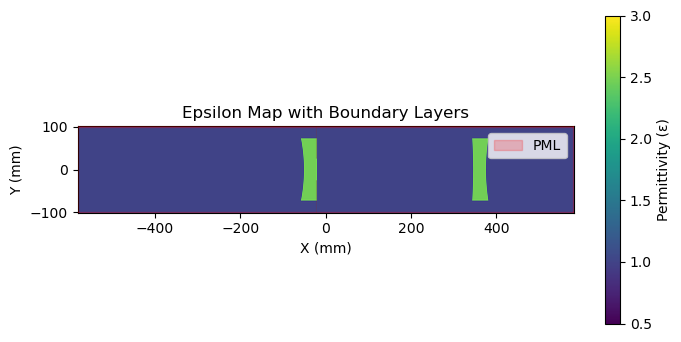

Epsilon plot saved to: auxilary_data/02_SPIDER2/output_files/geometry_plot.png
Epsilon data saved to: auxilary_data/02_SPIDER2/output_files/geometry_plot.h5


In [10]:
sim.plot_and_save_epsilon(
    simulation=simulation,
    savepath=savepath,
    filename_prefix="geometry_plot",
    epsilon_data_name="epsilon",
    size_x=size_x,
    size_y=size_y,
    vmin=0.5,
    vmax=3,
    cmap='viridis',
    figsize=(8, 4),
    dpi=300,
    show_plot= True
)

In [11]:
# Set the stepfunctions parameters
# Animation Parameters
stepfunctions.set_animation_params(anim_params= {'image_every': data["output"]["animation_options"]["image_every"], 
                                              'Nfps': data["output"]["animation_options"]["Nfps"], 
                                              'anim_file_name': savepath + "/"+ data["output"]["animation_options"]["movie_name"] + ".mp4"})
# Field Parameters
stepfunctions.set_field_params(field_params= {'size_x': size_x,
                                              'size_y': size_y,
                                              'savepath': savepath,
                                              'downsampling_factor_x': data["output"]["animation_options"]["downsample_x"],
                                              'downsampling_factor_y': data["output"]["animation_options"]["downsample_y"]})

# Runtime parameters
runtime_params = sim.calculate_runtime_parameters(
    source_freq=float(data["sources"]["source1"]["frequecy"]),
    total_time= 2500,
    animation_timestep = data["output"]["animation_options"]["image_every"],
    points_per_period=20,
    extraction_offset=10
)

Field extraction parameters set:
  size_x: 1162
  size_y: 202
  savepath: auxilary_data/02_SPIDER2/output_files
  downsampling_factor_x: 1
  downsampling_factor_y: 1
Runtime parameters calculated:
  Period: 2.5000 MEEP time units
  Time step (dt): 0.1250 MEEP time units
  Extraction start time (t0): 2490 MEEP time units
  Points per period: 20
  Animation timestep: 25 MEEP time units


In [ ]:
simulation.run(mp.at_every(runtime_params["animation_timestep"], stepfunctions.Ez2_dB),
               mp.after_time(runtime_params["t0"], mp.at_every(runtime_params["dt"], stepfunctions.accumulate_efield_and_hfield)),
               mp.at_end(stepfunctions.save_animation),
               mp.at_end(stepfunctions.save_accumulated_fields),
               mp.at_end(stepfunctions.extract_xyzw),
               until = runtime_params["total_time"])

print("Simulation completed.")                                                 

# #~ ---------------------------------------------

# Save the final edited JSON data
with open(data["output"]["savepath"]["path"] + data["simulation"]["name"] + "_simulation_data.json", "w") as f:
    json.dump(data, f, indent=2)
print(f"Simulation parameters saved to: {data['output']['savepath']['path']}{data['simulation']['name']}_simulation_data.json")

FloatProgress(value=0.0, description='0% done ', max=2500.0)

Meep progress: 0.9375/2500.0 = 0.0% done in 4.0s, 10708.7s to go
on time step 15 (time=0.9375), 0.267307 s/step
Meep progress: 2.5625/2500.0 = 0.1% done in 8.0s, 7819.7s to go
on time step 41 (time=2.5625), 0.154061 s/step
Meep progress: 4.25/2500.0 = 0.2% done in 12.1s, 7101.3s to go
on time step 68 (time=4.25), 0.150606 s/step
Meep progress: 5.9375/2500.0 = 0.2% done in 16.2s, 6806.3s to go
on time step 95 (time=5.9375), 0.15221 s/step
Meep progress: 7.625/2500.0 = 0.3% done in 20.3s, 6642.3s to go
on time step 122 (time=7.625), 0.152464 s/step
Meep progress: 9.3125/2500.0 = 0.4% done in 24.4s, 6533.9s to go
on time step 149 (time=9.3125), 0.152144 s/step
Meep progress: 11.0/2500.0 = 0.4% done in 28.5s, 6438.6s to go
on time step 176 (time=11), 0.149051 s/step
Meep progress: 12.6875/2500.0 = 0.5% done in 32.5s, 6368.6s to go
on time step 203 (time=12.6875), 0.149233 s/step
Meep progress: 14.375/2500.0 = 0.6% done in 36.5s, 6313.7s to go
on time step 230 (time=14.375), 0.149141 s/step